# 02 Metrics, Robustness, And Self-Healing Visualisations

Here I stress the scalar field instead of tuning it. I use obstruction and recovery plots to check whether the Bessel zone behaves like a self-healing beam and whether the metric traces tell the same story as the images.

In [1]:
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from vbb_study import setup_study, vbb_style

PATHS = setup_study.bootstrap(Path.cwd())
ROOT = PATHS["root"]
PUB_ROOT = PATHS["publication"]
LAB_ROOT = PATHS["modular_lab"]

import bessel_twin_core as bt
from Publication_Study import publication_diagnostics as pdiag

## Editable Notebook Controls

<!-- STAGE88: editable controls -->

This cell exposes the intended user-editable controls for exploratory runs. The locked stage logic below is preserved: changing these controls is for local investigation unless the notebook explicitly wires a value into a regenerated canonical output. Keep QA, caveats, and fail/marginal labels visible. For fast beam-to-sample exploration use the quicklook notebook; for publication-grade outputs use the locked stage runner.


In [ ]:
# STAGE88: visible editable controls for exploratory notebook use.
# Edit NOTEBOOK_CONTROLS below and re-run this cell to apply parameter
# overrides to `base` before running any study cell below.
from dataclasses import replace
from vbb_study.publication import notebook_controls as nb_controls
from vbb_study.config import um as _um

NOTEBOOK_CONTROLS = nb_controls.make_notebook_controls(
    stage='scalar',
    # ── edit these to override the base configuration ───────────────────────
    ell=3,
    target_core_diameter_um=3.0,
    target_bessel_length_um=150.0,
    objective_NA=0.45,
    blaze_period_px=20,
)

# Build a base config and wire control parameters into it.
base = bt.default_config("fast")
_p = NOTEBOOK_CONTROLS.parameters or {}
if "ell" in _p:
    base = replace(base, target=replace(base.target, ell=int(_p["ell"])))
if "target_core_diameter_um" in _p:
    base = replace(base, target=replace(base.target, target_core_diameter_m=float(_p["target_core_diameter_um"]) * _um))
if "target_bessel_length_um" in _p:
    base = replace(base, target=replace(base.target, target_bessel_length_m=float(_p["target_bessel_length_um"]) * _um))
if "objective_NA" in _p:
    base = replace(base, objective=replace(base.objective, NA=float(_p["objective_NA"])))
if "blaze_period_px" in _p:
    base = replace(base, slm=replace(base.slm, blaze_period_px=int(_p["blaze_period_px"])))

try:
    display(nb_controls.describe_controls(NOTEBOOK_CONTROLS))
except NameError:
    print(nb_controls.describe_controls(NOTEBOOK_CONTROLS).to_string(index=False))


In [ ]:
# Interactive quicklook — adjust sliders and click "Update plots".
# Runs a fast preview only; nothing is saved.
from vbb_study.publication import notebook_widgets as nbw

_panel = nbw.interactive_quicklook(base, method='holographic', preset='fast')
display(_panel)


In [2]:
# PHASE7: canonical schema import
# Imports the canonical scalar output schema helpers.
# source_schema_version is embedded in every row written to CSV.
from vbb_study.publication.tables import (
    SCALAR_OUTPUT_SCHEMA_VERSION,
    SCALAR_SUMMARY_COLUMNS,
    annotate_scalar_row,
    ordered_row,
    propagation_power_label as _power_label,
)
print(f"Scalar output schema version: {SCALAR_OUTPUT_SCHEMA_VERSION}")
print(f"Canonical columns: {len(SCALAR_SUMMARY_COLUMNS)} defined in tables.py")


Scalar output schema version: 2.0.0
Canonical columns: 30 defined in tables.py


In [3]:
# PHASE7: fast-preset caution
# This notebook was last executed with the 'fast' grid preset.
# The fast preset is a DIAGNOSTIC / DEBUG speed mode:
#   - small grid (N=512), coarse axial sampling
#   - may show propagation_power_label='fail' (>20% power drift)
#   - NOT suitable as the primary source for publication figures
#
# Publication preset improves propagation-power drift, but does NOT certify
# every case as publication-ready. Preserve propagation_power_label and inspect
# fail rows as numerical diagnostics or rerun with finer grid/sampling/model setup.
# See: tools/regen_scalar_shortlist.py --preset publication
#
# Cases with propagation_power_label='fail' MUST NOT be reported as
# publication-ready or hidden by threshold relaxation.
import os as _os
_rid = _os.environ.get("STRUCTURED_BEAM_RUN_ID", "interactive")
_preset_env = _os.environ.get("STRUCTURED_BEAM_PRESET", "fast")
print(f"[Phase7 caution] run_id={_rid!r}  preset={_preset_env!r}")
print("[Phase7 caution] Fast preset: results are diagnostic quality only.")
print("[Phase7 caution] Publication preset improves drift but may still leave fail cases.")


[Phase7 caution] run_id='20260603T200130Z'  preset='fast'
[Phase7 caution] Fast preset: results are diagnostic quality only.
[Phase7 caution] Publication preset improves drift but may still leave fail cases.


In [4]:
PRESET = "fast"
PUB_OUT = pdiag.publication_output_tree(PATHS["outputs"])
base = bt.default_config(PRESET)

## Thin-Screen Obstacle Campaign

The campaign uses a baseline ell = 3, core = 3 um, length = 150 um case and compares a few obstacle types at the same obstacle plane depth.

In [5]:
campaign = [
    {"case_id": "disk_small", "obstacle_kind": "disk", "obstacle_radius_m": 1.5 * bt.um},
    {"case_id": "disk_large", "obstacle_kind": "disk", "obstacle_radius_m": 2.5 * bt.um},
    {"case_id": "strip", "obstacle_kind": "strip", "obstacle_width_m": 2.0 * bt.um},
    {"case_id": "square", "obstacle_kind": "square", "obstacle_width_m": 2.5 * bt.um, "obstacle_height_m": 2.5 * bt.um},
]
ideal_bundles = [
    pdiag.build_self_healing_bundle(base, preset=PRESET, path="ideal", **spec)
    for spec in campaign
]
ideal_summary = pdiag.self_healing_summary_dataframe(ideal_bundles)
ideal_summary.to_csv(PUB_OUT["csv"] / "self_healing_campaign_ideal.csv", index=False)
display(ideal_summary)

,case_id,path,obstacle_kind,obstacle_z_um,blocked_fraction,peak_recovery_end,peak_recovery_max,peak_recovery_mean,onaxis_recovery_end,target_bessel_length_um,ell
0,disk_small,ideal,disk,52.5,0.000427,0.999752,1.127699,0.998717,0.630029,150.0,3
1,disk_large,ideal,disk,52.5,0.001205,1.002520,1.011374,0.921472,3.688061,150.0,3
2,strip,ideal,strip,52.5,0.015625,1.531466,1.531466,1.212772,144.941013,150.0,3
3,square,ideal,square,52.5,0.000381,1.004413,1.189859,1.011897,0.600651,150.0,3


## Selected Diagnostic Panel

Inspect one campaign member in detail: reference field at the obstacle, obstructed field, obstructed XZ evolution, and recovery traces.

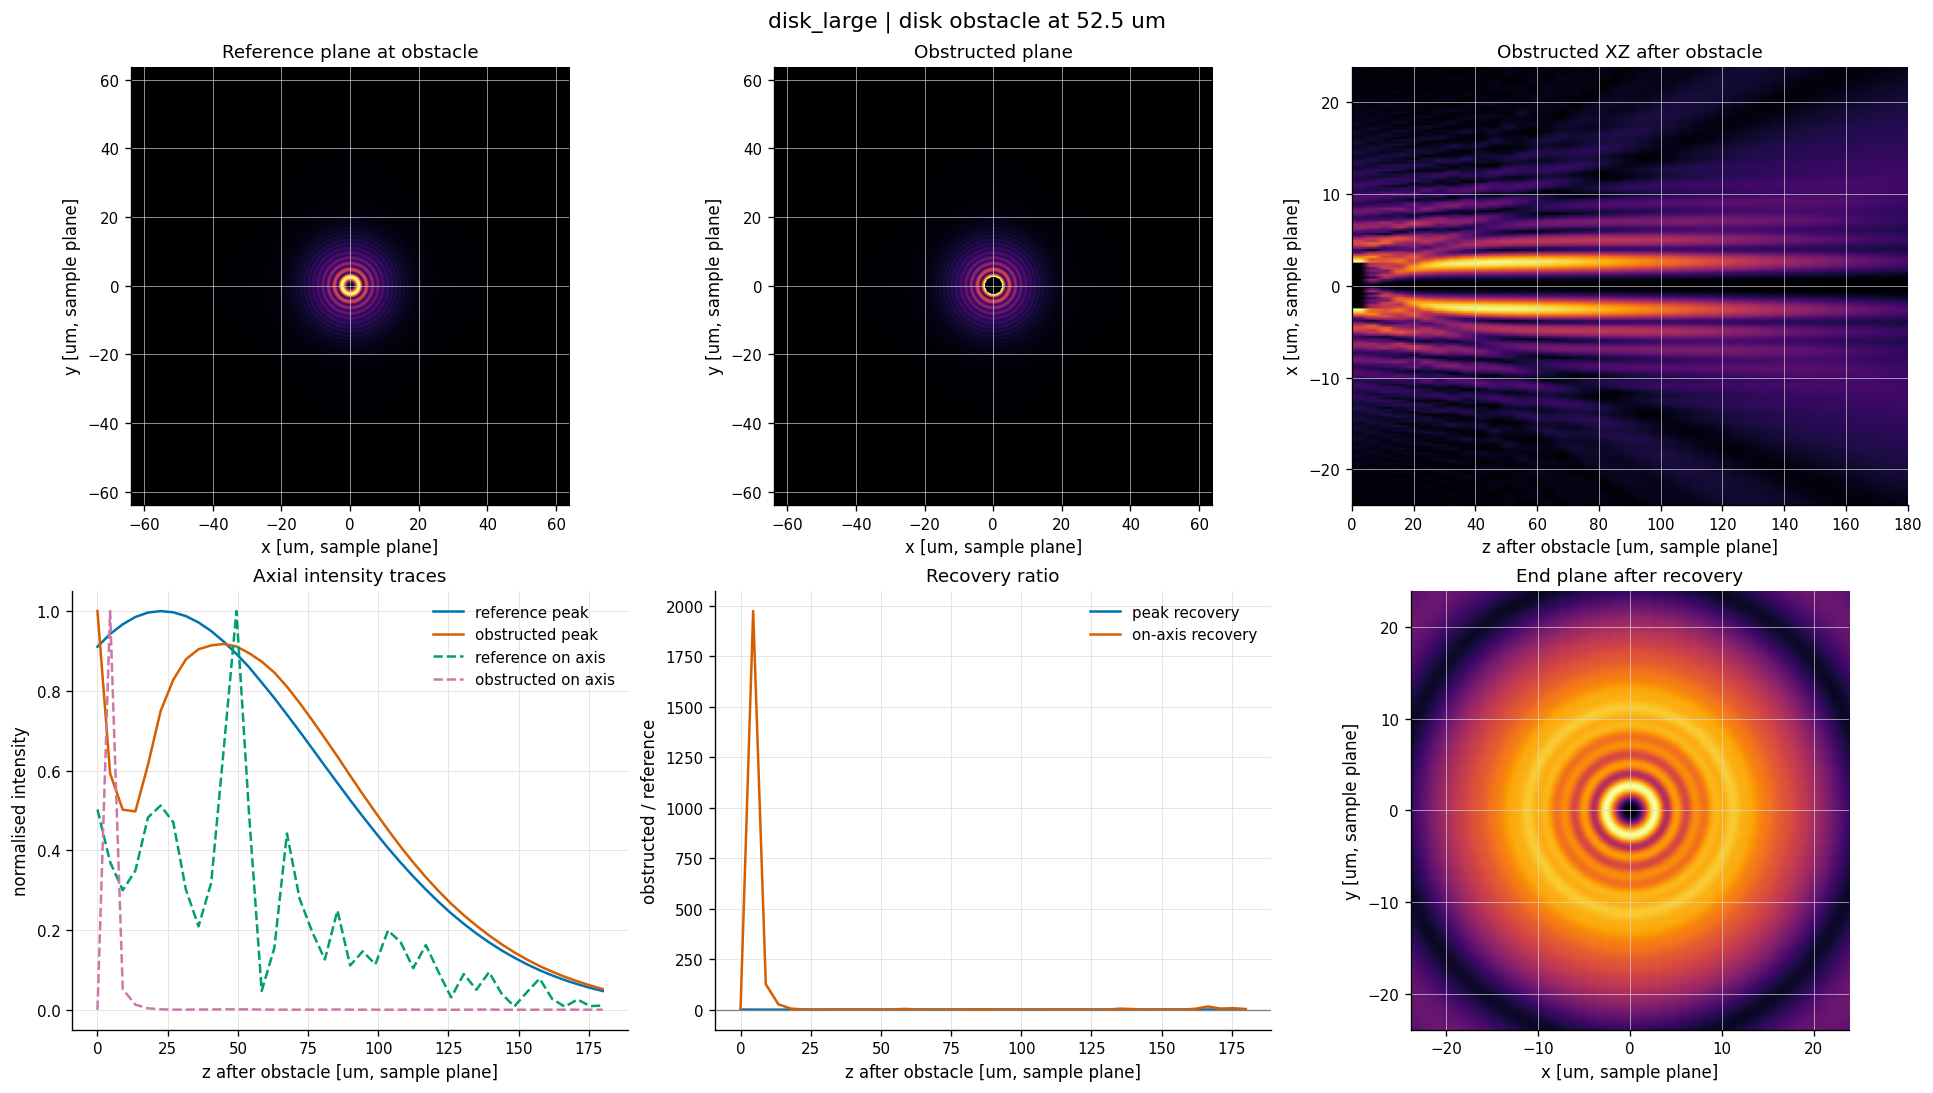

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\disk_large_self_healing_panel.png


In [6]:
SELECTED = "disk_large"
selected = next(bundle for bundle in ideal_bundles if bundle["case_id"] == SELECTED)
fig = pdiag.plot_self_healing_diagnostics(selected)
selected_path = PUB_OUT["figures"] / f"{SELECTED}_self_healing_panel.png"
fig.savefig(selected_path, dpi=220, bbox_inches="tight")
plt.show()
print(selected_path)

## Recovery Curve Comparison

Compare how the peak-in-plane recovery evolves for all ideal campaign members after the obstacle plane.

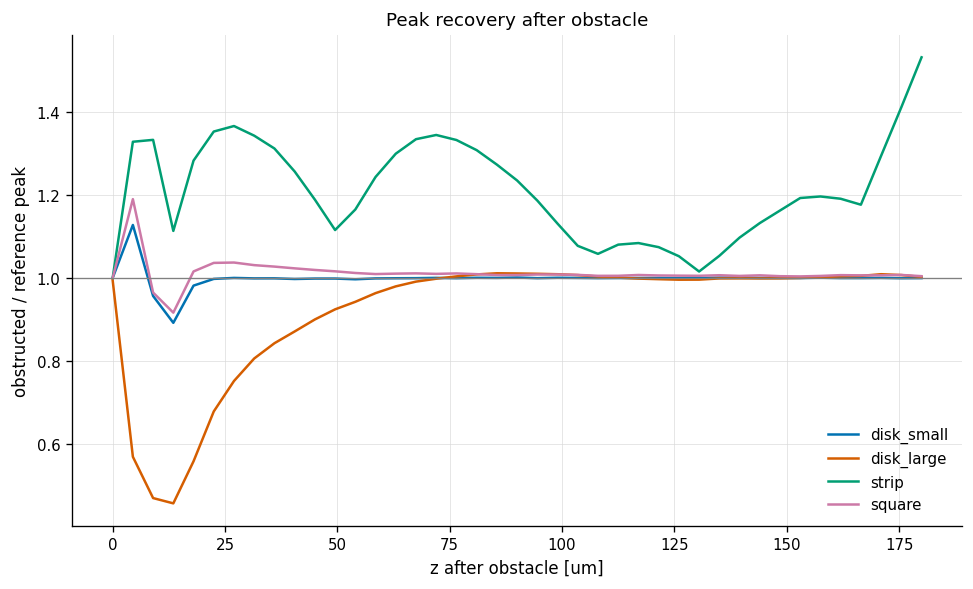

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\self_healing_recovery_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
for bundle in ideal_bundles:
    ax.plot(bundle["z_relative"] / bt.um, bundle["peak_recovery"], label=bundle["case_id"])
ax.axhline(1.0, color="0.5", linewidth=0.8)
ax.set_title("Peak recovery after obstacle")
ax.set_xlabel("z after obstacle [um]")
ax.set_ylabel("obstructed / reference peak")
ax.legend(frameon=False)
curve_path = PUB_OUT["figures"] / "self_healing_recovery_curves.png"
fig.savefig(curve_path, dpi=220, bbox_inches="tight")
plt.show()
print(curve_path)

## Realistic Benchmark

Repeat one obstruction with the realistic device-to-sample path so the paper can show that the robustness diagnostic layer also works on the lab-facing propagation route.

In [8]:
realistic_bundle = pdiag.build_self_healing_bundle(
    base,
    preset=PRESET,
    path="realistic",
    case_id="disk_large_realistic",
    obstacle_kind="disk",
    obstacle_radius_m=2.5 * bt.um,
)
compare = pd.DataFrame([selected["metrics"], realistic_bundle["metrics"]])
compare.to_csv(PUB_OUT["csv"] / "self_healing_realistic_benchmark.csv", index=False)
display(compare)

,case_id,path,obstacle_kind,obstacle_z_um,blocked_fraction,peak_recovery_end,peak_recovery_max,peak_recovery_mean,onaxis_recovery_end,target_bessel_length_um,ell
0,disk_large,ideal,disk,52.5,0.001205,1.002520,1.011374,0.921472,3.688061,150.0,3
1,disk_large_realistic,realistic,disk,52.5,0.001205,0.999782,1.014166,0.998742,0.970763,150.0,3


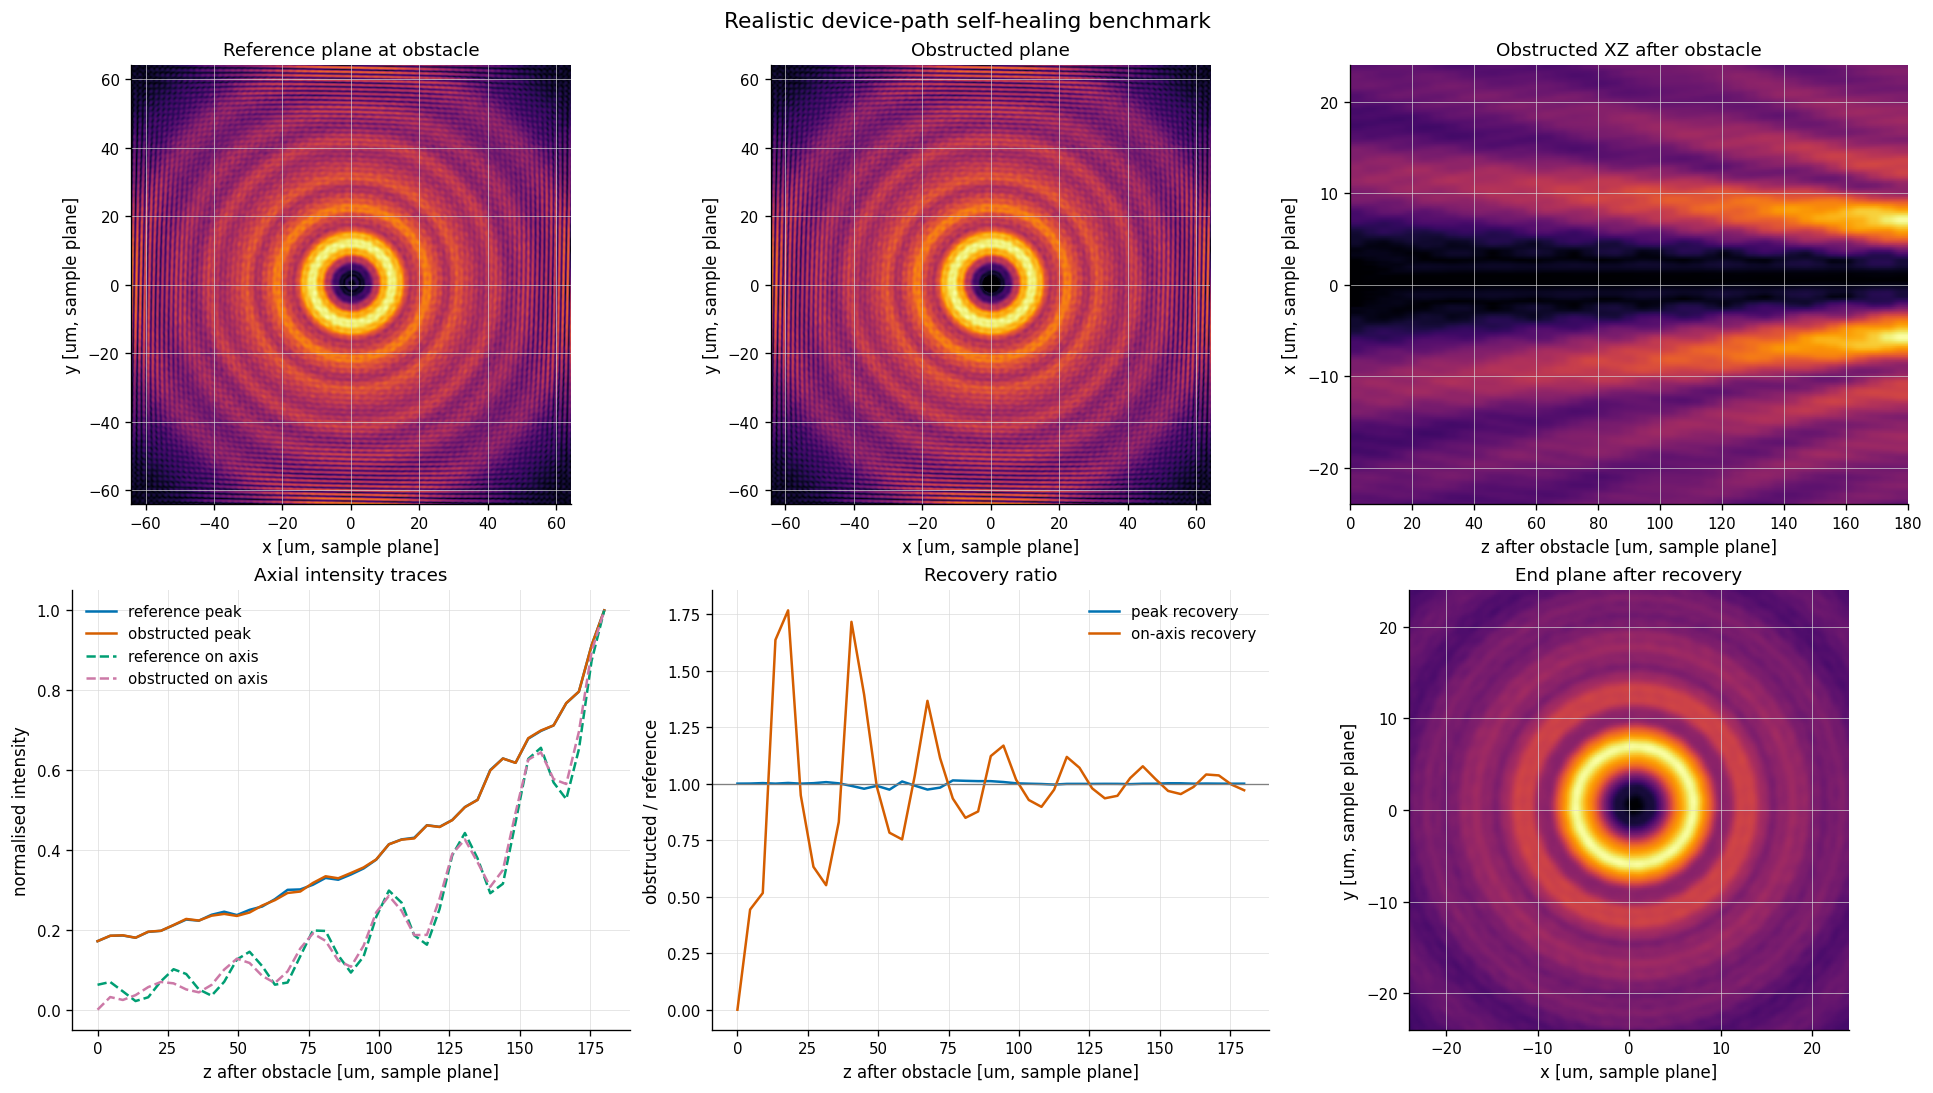

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\self_healing_realistic_benchmark.png


In [9]:
fig = pdiag.plot_self_healing_diagnostics(realistic_bundle, title="Realistic device-path self-healing benchmark")
realistic_path = PUB_OUT["figures"] / "self_healing_realistic_benchmark.png"
fig.savefig(realistic_path, dpi=220, bbox_inches="tight")
plt.show()
print(realistic_path)

In [10]:
# PHASE7: propagation power QA
# Check propagation power drift for all cases found in notebook global scope.
# pass <= 5%, marginal <= 20%, fail > 20%.
# Fast preset is diagnostic/debug only. Publication preset improves drift, but
# does not make every case publication-ready; fail rows stay visible and should
# be treated as numerical diagnostics or rerun with finer grid/sampling/model setup.
import pandas as pd  # noqa: F811 (safe re-import)
_found_qa = False
for _name in [
    "summary",
    "df",
    "shortlist_df",
    "summary_df",
    "comparison_table",
    "preset_comparison",
    "oat",
    "tradeoff",
    "ell_family",
    "device_realism",
    "interface_depth",
]:
    _df = globals().get(_name)
    if _df is not None and isinstance(_df, pd.DataFrame) and "propagation_power_label" in _df.columns:
        _qa_cols = ["preset", "case_id", "propagation_power_drift_fraction", "propagation_power_label"]
        _qa = _df[[c for c in _qa_cols if c in _df.columns]].copy()
        if "preset" not in _qa.columns:
            _qa["preset"] = globals().get("PRESET", "unknown")
        _summary = (
            _qa.groupby("preset", dropna=False)["propagation_power_label"]
            .value_counts()
            .unstack(fill_value=0)
            .reindex(columns=["pass", "marginal", "fail"], fill_value=0)
            .reset_index()
        )
        print(f"Power QA counts by preset for '{_name}':")
        print(_summary.to_string(index=False))
        _pass = int((_qa["propagation_power_label"] == "pass").sum())
        _marginal = int((_qa["propagation_power_label"] == "marginal").sum())
        _fail = int((_qa["propagation_power_label"] == "fail").sum())
        print(f"Power QA for '{_name}': {_pass} pass, {_marginal} marginal, {_fail} fail")
        if _fail > 0:
            print("WARNING: FAIL cases (>20% drift) are NOT suitable for publication figures.")
        if _marginal > 0:
            print("NOTE: MARGINAL cases (5-20% drift) — review before publication.")
        _found_qa = True
        break
if not _found_qa:
    print("NOTE: power QA cell ran — no scalar summary DataFrame found in scope yet.")
    print("      Re-run this cell AFTER the cell that builds 'summary' or 'shortlist_df'.")


NOTE: power QA cell ran — no scalar summary DataFrame found in scope yet.
      Re-run this cell AFTER the cell that builds 'summary' or 'shortlist_df'.


In [11]:
# PHASE7: canonical zone vs strict region
# These are TWO DIFFERENT metrics. Never plot or report them interchangeably.
#
#   canonical_zone_um       = axial peak FWHM (single observable, broader)
#   strict_bessel_region_um = triple-intersection fabrication region (narrower)
#
# Use strict_bessel_region_um for fabrication planning and heatmaps.
# Use canonical_zone_um for optical diagnostic comparisons.
import pandas as pd  # noqa: F811
_zone_found = False
for _name in ["summary", "df", "shortlist_df", "summary_df", "oat", "tradeoff"]:
    _df = globals().get(_name)
    if _df is not None and isinstance(_df, pd.DataFrame):
        _c, _s = "canonical_zone_um", "strict_bessel_region_um"
        if _c in _df.columns and _s in _df.columns:
            _id = "case_id" if "case_id" in _df.columns else _df.columns[0]
            _z = _df[[_id, _c, _s]].copy()
            _z["zone_margin_um"] = _z[_c] - _z[_s]
            _z["strict_fraction"] = (_z[_s] / _z[_c].replace(0, float("nan"))).round(3)
            print(f"Zone/region comparison for '{_name}' ({len(_z)} rows):")
            print(_z.to_string(index=False))
            print()
            print("  canonical_zone_um       = axial_peak_fwhm  (from bessel_zone_metrics)")
            print("  strict_bessel_region_um = strict_intersection_peak_power_radius (narrower)")
            _zone_found = True
            break
if not _zone_found:
    print("NOTE: zone/region cell — no scalar summary DataFrame with both zone columns found.")
    print("      Re-run after the cell that builds 'summary' or 'shortlist_df'.")


NOTE: zone/region cell — no scalar summary DataFrame with both zone columns found.
      Re-run after the cell that builds 'summary' or 'shortlist_df'.
